In [1]:
import torch as t

In [4]:
t.__version__

'2.5.1'

# 初始化
- 你有的想法，开发者都给你用函数实现了

### Tensor 的基本操作

学习过NumPy的读者会对本节内容感到非常熟悉，因为Tensor的接口设计得与Numpy类似，以方便用户使用。当然，若读者不熟悉Numpy也没关系，本节内容并不要求读者事先掌握Numpy。

从接口的角度来讲，对Tensor的操作可分为两类：

1. `torch.function`，如`torch.save`等。
2. `tensor.function`，如`tensor.view`等。

为方便使用，对Tensor的大部分操作同时支持这两类接口，在本书中不做具体区分，如`torch.sum(a, b)`与`a.sum(b)`功能等价。

而从存储的角度来讲，对Tensor的操作又可分为两类：

1. 不会修改自身的数据，如 `a.add(b)`， 加法的结果会返回一个新的Tensor。
2. 会修改自身的数据，如 `a.add_(b)`， 加法的结果仍存储在a中，a被修改了。

函数名以`_`结尾的都是inplace方式，即会修改调用者自己的数据，在实际应用中需加以区分。

#### 创建Tensor

在PyTorch中创建Tensor的方法有很多，具体如表3-1所示：

表3-1: 常见创建Tensor的方法

|函数|功能|
|:---:|:---:|
|Tensor(\*sizes)|基础构造函数|
|tensor(data,)|类似np.array的构造函数|
|ones(\*sizes)|全1的Tensor|
|zeros(\*sizes)|全0的Tensor|
|eye(\*sizes)|对角线为1，其他为0|
|arange(s,e,step)|从s到e，步长为step|
|linspace(s,e,steps)|从s到e，均匀切分成steps份|
|rand / randn(\*sizes)|均匀/标准分布|
|normal(mean,std) / uniform(from,to)|正态分布/均匀分布|
|randperm(m)|随机排列|
|tensor.new_\* / torch.\*_like | 创建一个相同size大小，用*类型去填充（如tensor.new_ones就是使用全一的数据去填充）的张量，具有相同的torch.dtype和torch.device|

这些创建方法都可以在创建的时候指定数据类型dtype和存放device(CPU/GPU)。

使用`Tensor`函数新建Tensor可以接收一个list，并根据list的数据新建Tensor，同时也能根据指定的形状新建Tensor，还能传入其他的Tensor，下面将举几个例子说明。


In [5]:
x = t.rand(3, 5) 
x

tensor([[0.5109, 0.7468, 0.8003, 0.6805, 0.8881],
        [0.7547, 0.2025, 0.4183, 0.3436, 0.6759],
        [0.5518, 0.1369, 0.3951, 0.8376, 0.3332]])

In [8]:
# 指定Tensor的形状
a = t.Tensor(2, 3)
a # 数值取决于内存空间的状态，print时候可能overflow



tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [9]:
# 用list的数据创建Tensor
b = t.Tensor([[1,2,3],[4,5,6]])
b

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [10]:
b.tolist() # 把Tensor转为list

[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]

In [11]:
# 创建一个形状是(2,3)值全为1的Tensor
t.ones(2, 3)

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [12]:
# 创建一个对角线为1，其余为0的Tensor,不要求行列数一致
t.eye(2, 3, dtype=t.int)

tensor([[1, 0, 0],
        [0, 1, 0]], dtype=torch.int32)

In [13]:
# 创建一个均匀间距的Tensor，将1到10的数分为3份
t.linspace(1, 10, 3)

tensor([ 1.0000,  5.5000, 10.0000])

# 索引操作

- Tensor支持与numpy.ndarray类似的索引操作，语法上也类似，下面将通过一些例子讲解常用的索引操作。其中，能通过修改张量stride/start/dim等属性实现的索引操作与原Tensor共享内存，也就是说如果修改其中一个，另一个会跟着修改。

In [16]:
x = t.randn(3, 4) 
x

tensor([[-0.5076,  1.4027,  0.9208, -0.5977],
        [-0.6287, -0.1864, -0.3217, -1.1682],
        [-2.4946,  2.8252,  0.7763,  1.3461]])

In [17]:
x[0]

tensor([-0.5076,  1.4027,  0.9208, -0.5977])

In [18]:
x[0][1]

tensor(1.4027)

In [19]:
print(x.masked_select(x>0)) 

tensor([1.4027, 0.9208, 2.8252, 0.7763, 1.3461])


# 改变tensor的维度
- 所有改变Tensor形状的操作都可以通过`tensor.reshape`实现。`tensor.reshape(new_shape)`会把不连续的Tensor变成连续的再进行形状变化，这一操作等价于`tensor.contiguous().view(new_shape)`。关于`view`和`reshape`的选用可参考下面的建议:

1. 对于`reshape`而言:其接口更便捷，会自动把不连续的Tensor变为连续的，能避免很多报错。同时它的函数名和NumPy一样，便于使用。
2. 对于`view`而言:其函数名
`reshape`和`view`二者之间有一些区别：如果对Tensor使用了`transpose`、`permute`等操作，会造成Tensor的内存变得不连续，而`view`方法只能改变连续的张量，所以需要先调用`contiguous()`方法，但`reshape`方法则不受此限制。具体来说，`view`方法返回的Tensor和原Tensor共享Storage（注意：不是共享内存地址），而`reshape`方法可能返回原Tensor的copy或者共享Storage的view。如果当前满足连续性条件，则结果与`view`相同；否则返回的就是copy（此时等价于`tensor.contiguous().view()`）。更短，而且Tensor经过`view`操作之后仍然共享存储空间。当我们并不希望改变形状之后的Tensor和原Tensor共享存储时可以使用`view`方法。


In [21]:
a = t.arange(1, 13)
b = a.view(2, 6)
c = a.reshape(2, 6)
b,c

(tensor([[ 1,  2,  3,  4,  5,  6],
         [ 7,  8,  9, 10, 11, 12]]),
 tensor([[ 1,  2,  3,  4,  5,  6],
         [ 7,  8,  9, 10, 11, 12]]))

In [22]:
b = b.t() # b 不再连续
b.reshape(-1, 4) # reshape 可以

# 下面会报错，view无法在改变数据存储的情况下进行形状变化
# b.view(-1, 4)

tensor([[ 1,  7,  2,  8],
        [ 3,  9,  4, 10],
        [ 5, 11,  6, 12]])

In [23]:
b.view(-1, 4)

RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

reshape操作的难点在于如何快速灵活地指定形状，常用的快捷变形方法有：

1. `tensor.view(dim1,-1,dimN)`: 在调整Tensor形状的时候，我们不需要指定每一维的形状，可以把其中一个维度指定为-1，PyTorch会自动计算对应的形状
2. `tensor.view_as(other)`: 将Tensor的形状变为和other 一样，等价于`tensor.view(other.shape)`
3. `tensor.squeeze()`: 将Tensor形状中为`1`的维度去掉，比如(1,3,1,4)变为(3,4)
4. `tensor.flatten(start_dim=0, end_dim=-1)`: 将Tensor形状中某些连续维度合并为一个维度. 比如形状(2,3,4,5) ->(2,12,5)。
5. `tensor[None]` 和`tensor.unsqueeze(dim)`: 为Tensor新建一个维度，并把形状设为1, 比如形状(2,3) -> (2,1,3)

### 转置`torch.transpose/tensor.permute`

注意，Tensor的转置（transpose）和改变形状（reshape）是两个不一样的概念。比如将一张图片旋转90度，就属于向量的转置，无法通过单纯的改变向量形状实现。

`transpose`和`permute`函数都可以用于高维矩阵的转置，但用法上稍有区别：`transpose`只能用于两个维度的转置，意思就是只能改变两个维度的信息，而`permute`可以对任意高维矩阵进行转置，直接输入转置后维度index即可。我们可以通过多次`transpose`变换达到和`permute`相同的效果。常用的转置操作还有`tensor.t()`和`tensor.T`，它们和`tensor.transpose()`一样都属于`permute`的特例。

另外，向量的转置操作大多数情况下和输入的Tensor共享存储，但是会使得向量变得不连续, 此时最好通过`tensor.contiguous()`将它变成连续。但是有些操作(比如`tensor.sum/max`)支持不连续的Tensor，那么你可以不用将它变成连续, 这样可以节省内存/显存。

In [24]:
mask = t.arange(6).view(2,3) # 一张高为2，宽为3的图片
mask

tensor([[0, 1, 2],
        [3, 4, 5]])

In [25]:
# 将图片旋转90度, 也就是第一个维度(0)和第二个维度交换
# 等价于mask.transpose(1,0)
# 等价于mask.t() 或 img.T
# 等价于mask.permute(1,0), 不等价于img.permute(0,1)
mask.transpose(0,1)

tensor([[0, 3],
        [1, 4],
        [2, 5]])

In [26]:
 # 单纯地改变图片的形状
# 注意和上面的区别，结果仍然是连续的
mask.view(3,2)

tensor([[0, 1],
        [2, 3],
        [4, 5]])

In [27]:
import torch as t

x = t.tensor([1, 2, 3, 4])      # shape == (4,)
print(x.unsqueeze(0).shape)     # torch.Size([1, 4])  变成行向量
print(x.unsqueeze(1).shape)     # torch.Size([4, 1])  变成列向量
print(x.unsqueeze(-1).shape)    # torch.Size([4, 1])  负数同样 ok

torch.Size([1, 4])
torch.Size([4, 1])
torch.Size([4, 1])


In [28]:
x 

tensor([1, 2, 3, 4])

In [29]:
x.unsqueeze(0)

tensor([[1, 2, 3, 4]])

In [41]:
x.unsqueeze(1)

tensor([[1],
        [2],
        [3],
        [4]])

In [42]:
y = t.zeros(2, 1, 3, 1, 4)      # shape == (2, 1, 3, 1, 4)
print(y.squeeze().shape)        # (2, 3, 4)      全挤压
print(y.squeeze(1).shape)       # (2, 3, 1, 4)   只挤第 1 维
print(y.squeeze(2).shape)  

torch.Size([2, 3, 4])
torch.Size([2, 3, 1, 4])
torch.Size([2, 1, 3, 1, 4])


In [43]:
y 

tensor([[[[[0., 0., 0., 0.]],

          [[0., 0., 0., 0.]],

          [[0., 0., 0., 0.]]]],



        [[[[0., 0., 0., 0.]],

          [[0., 0., 0., 0.]],

          [[0., 0., 0., 0.]]]]])

In [44]:
y.squeeze()

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]])

In [45]:
y.squeeze(1)

tensor([[[[0., 0., 0., 0.]],

         [[0., 0., 0., 0.]],

         [[0., 0., 0., 0.]]],


        [[[0., 0., 0., 0.]],

         [[0., 0., 0., 0.]],

         [[0., 0., 0., 0.]]]])

# 神经网络工具箱nn
- 通过pytorch搭建神经网络中常用的工具，比如nn网络层、优化器optim、初始化init等。
- 使用autograd可实现深度学习模型，但其抽象程度较低，如果用其来实现深度学习模型，则需要编写的代码量极大。在这种情况下，torch.nn便应运而生，它是专门为深度学习而设计的模块。torch.nn的核心数据结构是`Module`，它是一个抽象的概念，既可以表示神经网络中的某个层（layer），也可以表示一个包含很多层的神经网络。在实际使用中，最常见的做法是继承`nn.Module`，从而编写自己的网络/层。下面先来看看如何用`nn.Module`实现自己的全连接层。全连接层，又名仿射层，输出$\textbf{y}$和输入$\textbf{x}$满足$\textbf{y=Wx+b}$，其中$\textbf{W}$和$\textbf{b}$是可学习的参数。

In [47]:
import torch as t
from torch import nn
class Linear(nn.Module): # 继承nn.Module，必须重写构造函数（__init__)和前向传播函数（forward）
    def __init__(self, in_features, out_features):
        super().__init__() # 等价于nn.Module.__init__(self)，常用super方式
        # nn.Parameter内的参数是网络可学习的参数
        self.w = nn.Parameter(t.randn(in_features, out_features))
        self.b = nn.Parameter(t.randn(out_features))
    
    def forward(self, x):
        x = x.mm(self.w) # 矩阵乘法，等价于x.@(self.w)
        return x + self.b.expand_as(x)
layer = Linear(4,3)
input = t.randn(2,4)
output = layer(input)
output

tensor([[-1.5670,  5.5157, -2.3398],
        [ 0.0922,  5.1495, -3.6799]], grad_fn=<AddBackward0>)

In [48]:
for name, parameter in layer.named_parameters():
    print(name, parameter) # w and b 

w Parameter containing:
tensor([[-0.5720,  2.2296, -1.1956],
        [ 1.8505, -0.0331, -0.2793],
        [ 0.9718, -0.5927,  0.6098],
        [ 0.4688,  1.9710, -0.3524]], requires_grad=True)
b Parameter containing:
tensor([-0.1508,  2.5880, -1.1314], requires_grad=True)


从上面的例子中可以看出，全连接层的实现非常简单，其代码量不超过10行，但需注意以下几点：
- 自定义层`Linear`必须继承`nn.Module`，并且在其构造函数中需调用`nn.Module`的构造函数，即`super().__init__()` 或`nn.Module.__init__(self)`，推荐使用第一种用法；
- 在构造函数`__init__`中必须自行定义可学习的参数，并封装成`Parameter`，如在本例中我们把`w`和`b`封装成`Parameter`。`Parameter`是一种特殊的`Tensor`，但其默认需要求导（requires_grad = True），感兴趣的读者可以通过`nn.Parameter??`，查看`Parameter`类的源代码；
- `forward`函数实现前向传播过程，其输入可以是一个或多个Tensor；
- 无需写反向传播函数，`nn.Module`能够利用autograd自动实现反向传播，这点比Function简单许多；
- 使用时，直观上可将layer看成数学概念中的函数，调用layer(input)即可得到input对应的结果。它等价于`layers.__call__(input)`，在`__call__`函数中，主要调用的是 `layer.forward(x)`，另外还对钩子（hook）做了一些处理。所以在实际使用中应尽量使用`layer(x)`而不是使用`layer.forward(x)`，关于钩子技术将在下文讲解；
- `Module`中的可学习参数可以通过`named_parameters()`或者`parameters()`返回一个迭代器，前者会给每个parameter都附上名字，使其更具有辨识度。

可见利用Module实现的全连接层，比利用`Function`实现的更为简单，这是因为我们不再需要编写反向传播函数。

Module能够自动检测到自己的`parameter`，并将其作为学习参数。除了`parameter`之外，Module还包含子`Module`，主Module能够递归查找子`Module`中的`Parameter`。下面再来看看稍微复杂一点的网络，多层感知机。

## 常用神经网络层-图像相关层
- 图像相关层主要包括卷积层（Conv）、池化层（Pool）等，这些层在实际使用中可分为一维（1D）、二维（2D）和三维（3D），池化方式又分为平均池化（AvgPool）、最大值池化（MaxPool）、自适应池化（AdaptiveAvgPool）等。而卷积层除了常用的前向卷积之外，还有逆卷积（TransposeConv）等等。下面将举例说明。
- 在torch.nn工具箱中，已经封装好了二维卷积类 ： 
```python
torch.nn.Conv2d(in_channels: int,   
                out_channels: int,  
                kernel_size: Union[T, Tuple[T, T]], 
                stride: Union[T, Tuple[T, T]] = 1, 
                padding: Union[T, Tuple[T, T]] = 0, 
                dilation: Union[T, Tuple[T, T]] = 1, 
                groups: int = 1, bias: bool = True, 
                padding_mode: str = 'zeros')  
```
其中：  
- in_channels：输入图像的维度（常见RGB彩色图像为3）；
- out_channels：经过卷积操作后输出的维度；
- kernel_size：卷积核大小，常见卷积核为2维方阵即维度为$[T\times T]$，正方形卷积核可以写为$T(int)$；
- stride：每次卷积操作移动的步长；
- padding：卷积操作在边界是否有填充，默认为0；
- bias：卷积操作加上偏置作为可学习参数，默认为True。


- 在卷积操作中，我们需要知道其输出结果的形状，以便对后续网络结构进行设计。假设输入的形状为$（N,C_{in},H_{in},W_{in})$，输出的形状为$（N,C_{out},H_{out},W_{out})$，则可以通过式(4.1)计算：
$$ \begin{array}{l}
   H_{out} = \lfloor {H_{in}+{2}\times{padding[0]}-kernel\_size[0] \over stride[0]}+1 \rfloor \\
   W_{out} = \lfloor {W_{in}+{2}\times{padding[1]}-kernel\_size[1] \over stride[1]}+1 \rfloor
  \end{array}\tag{4.1}
$$ 
下面将举例说明卷积操作的具体过程。

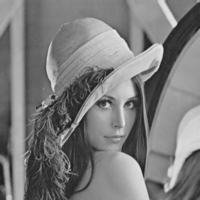

In [22]:
from PIL import Image
import torch as t
from torch import nn
from torchvision.transforms import ToTensor, ToPILImage
to_tensor = ToTensor() # img -> tensor
to_pil = ToPILImage()
lena = Image.open('lena.png')
lena#将lena可视化输出

In [18]:
# 输入是一个batch，batch_size＝1
lena = to_tensor(lena).unsqueeze(0) 
print("Input Size:",lena.size())#查看input纬度

Input Size: torch.Size([1, 3, 1500, 2250])


In [24]:
from torchvision.transforms import functional as TF

lena = Image.open('lena.png')          # RGB
lena_gray = TF.to_grayscale(lena)      # 变成 1 通道
lena_tensor = TF.to_tensor(lena_gray).unsqueeze(0)   # [1,1,H,W]

Output Size: torch.Size([1, 1, 200, 200])


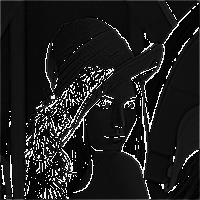

In [25]:

# 锐化卷积核
kernel = t.ones(3, 3) / (-9.)
kernel[1][1] = 1
conv = nn.Conv2d(1, 1, (3,3), 1, padding=1, bias=False)
conv.weight.data = kernel.view(1, 1, 3, 3)

out = conv(lena_tensor)
print("Output Size:",out.size())
to_pil(out.data.squeeze(0))

#### 池化层

池化层可以看作是一种特殊的卷积层，其主要用于下采样，增加池化层可以在保留主要特征的同时降低参数量，从而一定程度上防止了过拟合。池化层没有可学习参数，它的weight是固定的。在`torch.nn`工具箱中封装好了各种池化层，常见的有最大池化（MaxPool）和平均池化（AvgPool)，下面将举例说明。

In [26]:
input = t.randint(10,(1,1,4,4))
print(input)
pool = nn.AvgPool2d(2,2) # 平均池化，池化中的卷积核为2*2，步长默认等于卷积核长度，无填充
pool(input)

tensor([[[[1, 7, 1, 1],
          [9, 0, 5, 6],
          [5, 1, 2, 8],
          [7, 6, 2, 0]]]])


tensor([[[[4, 3],
          [4, 3]]]])

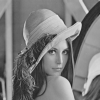

In [28]:
out = pool(lena_tensor)
to_pil(out.data.squeeze(0))#输出池化后的lena

#### 其他层

除了卷积层和池化层，深度学习中还将常用到以下几个层：
- Linear：全连接层；
- BatchNorm：批标准化层，分为1D、2D和3D。除了标准的BatchNorm之外，还有在风格迁移中常用到的InstanceNorm层；
- Dropout：Dropout层，用来防止过拟合，同样分为1D、2D和3D。

下面将举几个例子来说明它们的使用方法。

In [29]:
# 输入 batch_size=2，维度3
input = t.randn(2, 3)
linear = nn.Linear(3, 4)
h = linear(input)
h

tensor([[-1.0529, -0.2050,  1.7663,  1.8543],
        [ 0.5298,  1.0580, -0.0232,  0.8659]], grad_fn=<AddmmBackward0>)

In [30]:
# 4 channel，初始化标准差为4，均值为0
bn = nn.BatchNorm1d(4)
bn.weight.data = t.ones(4) * 4
bn.bias.data = t.zeros(4)

bn_out = bn(h)
print(bn_out)
# 注意输出的均值和方差
bn_out.mean(0),bn_out.std(0, unbiased=False)

tensor([[-4.0000, -3.9999,  4.0000,  3.9999],
        [ 4.0000,  3.9999, -4.0000, -3.9999]],
       grad_fn=<NativeBatchNormBackward0>)


(tensor([ 0.0000e+00,  0.0000e+00, -2.3842e-07, -2.3842e-07],
        grad_fn=<MeanBackward1>),
 tensor([4.0000, 3.9999, 4.0000, 3.9999], grad_fn=<StdBackward0>))

### 激活函数
PyTorch实现了常见的激活函数，其具体的接口信息可参见官方文档，这些激活函数可作为独立的layer使用。这里将介绍最常用的激活函数ReLU，其数学表达式为：
$$
ReLU(x)=max(0,x) \tag{4.2}
$$

下面来看如何在`torch.nn`中使用ReLU函数：

In [31]:
relu = nn.ReLU(inplace=True)
input = t.randn(2, 3)
print(input)
output = relu(input)
print(output) # 小于0的都被截断为0
# 等价于input.clamp(min=0)

tensor([[-0.2619, -0.2232, -0.9855],
        [ 1.0942, -1.0243,  0.9364]])
tensor([[0.0000, 0.0000, 0.0000],
        [1.0942, 0.0000, 0.9364]])


## nn.functional
- `torch.nn`中还有一个很常用的模块：`nn.functional`。`torch.nn`中的大多数layer，在`functional`中都有一个与之相对应的函数。`nn.functional`中的函数和`nn.Module`的主要区别在于，用`nn.Module`实现的layers是一个特殊的类，都是由`class layer(nn.Module)`定义，会自动提取可学习的参数；而`nn.functional`中的函数更像是纯函数，由`def function(input)`定义。下面将举例说明functional的使用，并对比二者的不同之处。

In [32]:
input = t.randn(2, 3)
model = nn.Linear(3, 4)
output1 = model(input)
output2 = nn.functional.linear(input, model.weight, model.bias)
output1 == output2

tensor([[True, True, True, True],
        [True, True, True, True]])

## 优化器

PyTorch将深度学习中常用的优化方法全部封装在`torch.optim`中，其设计十分灵活，能够很方便地扩展成自定义的优化方法。

所有的优化方法都是继承基类`optim.Optimizer`，并实现了自己的优化步骤。下面就以最基本的优化方法——随机梯度下降法（SGD）举例说明。这里需要重点掌握：

1. 优化方法的基本使用方法；
2. 如何对模型的不同部分设置不同的学习率；
3. 如何调整学习率。

In [34]:
# 以本章4.1节的感知器为例
class Perceptron(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(Perceptron, self).__init__()
        # 此处的Linear是前面自定义的全连接层
        self.layer1 = nn.Linear(in_features, hidden_features) 
        self.layer2 = nn.Linear(hidden_features, out_features)
    def forward(self, x):
        x = self.layer1(x)
        x = t.sigmoid(x)
        return self.layer2(x)

net=Perceptron(3,4,1)

In [35]:
from torch import optim
optimizer = optim.SGD(params=net.parameters(), lr=1)
optimizer.zero_grad() # 梯度清零，等价于net.zero_grad()

input = t.randn(32, 3)
output = net(input)
output.backward(output) # fake backward

optimizer.step() # 执行优化

In [36]:
weight_params = [param for name,param in net.named_parameters() if name.endswith('.w')]
bias_params = [param for name,param in net.named_parameters() if name.endswith('.b')]

optimizer =optim.SGD([
                {'params':bias_params},
                {'params': weight_params, 'lr': 1e-2}
            ], lr=1e-5)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [37]:
# 只为第一个全连接层设置较大的学习率，其余层的学习率较小
special_layers = nn.ModuleList([net.layer1])
special_layers_params = list(map(id, special_layers.parameters()))
base_params = [param for param in net.parameters() if id(param) not in special_layers_params]
optimizer = t.optim.SGD([
            {'params': base_params},
            {'params': special_layers.parameters(), 'lr': 0.01}
        ], lr=0.001 )
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

调整学习率主要有两种做法：
1. 修改optimizer.param_groups中对应的学习率；
2. 新建一个优化器。

相比之下笔者更加推荐第二种做法，这是因为optimizer一般构建开销很小，故而可以构建新的optimizer。但是新建优化器会重新初始化动量等状态信息，这对于使用动量的优化器（如Adam），可能会造成损失函数在收敛过程中出现震荡等情况。

In [38]:
# 调整学习率，新建一个optimizer
old_lr = 0.1
optimizer1 =optim.SGD([
                {'params': bias_params},
                {'params': weight_params, 'lr': old_lr*0.1}
            ], lr=1e-5)
optimizer1

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.010000000000000002
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [39]:
# 调整学习率, 手动decay, 保存动量
for param_group in optimizer.param_groups:
    param_group['lr'] *= 0.1 # 学习率为之前的0.1倍
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0

Parameter Group 1
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### 数据处理

在解决深度学习问题的过程中，我们往往需要花费大量的精力去处理数据，包括图像、文本、语音或其它二进制数据等。数据的处理对训练神经网络来说十分重要，良好的数据处理不仅会加速模型训练，也会提高模型效果。考虑到这点，PyTorch提供了几个高效便捷的工具，以便使用者进行数据处理或数据增强等操作，同时可通过并行化加速数据的加载过程。

#### Dataset

在PyTorch中，数据加载可通过自定义的数据集对象实现。数据集对象被抽象为`Dataset`类，实现自定义的数据集需要继承`Dataset`，并实现两个Python魔法方法：
- `__getitem__()`：返回一条数据，或一个样本。`obj[index]`等价于`obj.__getitem__(index)`；
- `__len__()`：返回样本的数量。`len(obj)`等价于`obj.__len__()`。

In [40]:
import torch as t
from torch.utils.data import Dataset
print(t.__version__)

2.5.1


In [41]:
import os
from PIL import Image
import numpy as np

class DogCat(Dataset):
    def __init__(self, root):
        imgs = os.listdir(root)
        # 所有图片的绝对路径
        # 这里不实际加载图片，只是指定路径，当调用__getitem__时才会真正读图片
        self.imgs = [os.path.join(root, img) for img in imgs]
        
    def __getitem__(self, index):
        img_path = self.imgs[index]
        # dog->1， cat->0
        label = 1 if 'dog' in img_path.split('/')[-1] else 0
        pil_img = Image.open(img_path)
        array = np.asarray(pil_img)
        data = t.from_numpy(array)
        return data, label
    
    def __len__(self):
        return len(self.imgs)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
dataset = DogCat('./data/dogcat/')
img, label = dataset[0] # 相当于调用dataset.__getitem__(0)
for img, label in dataset:
    print(img.size(), img.float().mean(), label)

针对上述问题，PyTorch提供了torchvision。torchvision是一个视觉工具包，提供了很多视觉图像处理的工具，其中`transforms`模块提供了一系列数据增强的操作。本章仅对其部分操作进行介绍，完整内容可参考官方相关文档。

对PIL Image的部分操作包括：
- `Resize`：调整图片尺寸；
- `RandomAffine`： 对图像进行仿射变换；
- `CenterCrop`、`RandomCrop`、`RandomResizedCrop`、`FiveCrop`： 对图像按不同规则进行裁剪；
- `ColorJitter`： 修改图像的亮度、对比度以及饱和度；
- `Pad`：对图像进行填充；
- `ToTensor`：将$H\times W\times C$维度的PIL Image对象转成维度为$C\times H\times W$的Tensor，同时会自动将\[0, 255]归一化至\[0, 1]。

对Tensor的部分操作包括：
- `Normalize`：标准化，即减均值，除以标准差；
- `ToPILImage`：将Tensor转为PIL Image对象；
- `RandomErasing`：随机擦除图像中矩形区域的部分像素。

对Transforms的操作包括：
- `RandomApply`：对一个transforms按一定概率执行；
- `RandomChoice`：从一系列transforms随机执行一个操作；
- `RandomOrder`：对一系列transforms操作按随机顺序执行。  

如果要对图片进行多个操作，可通过`transforms.Compose`将这些操作拼接起来，类似于`nn.Sequential`。注意，这些操作定义后是以对象形式存在的，真正使用时需调用它的`__call__`方法，这点类似于`nn.Module`。例如要将图片调整为$224\times 224$，首先应构建这个操作`trans = Resize((224, 224))`，然后调用`trans(img)`。下面我们就用transforms的这些操作来优化上面实现的dataset。 


In [ ]:
import os
from PIL import  Image
import numpy as np
from torchvision import transforms as T

transform = T.Compose([
    T.Resize(224), # 缩放图片(Image)，保持长宽比不变，最短边为224像素
    T.CenterCrop(224), # 从图片中间切出224*224的图片
    T.ToTensor(), # 将图片(Image)转成Tensor，归一化至[0, 1]
    T.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5]) # 标准化至[-1, 1]，规定均值和标准差
])

class DogCat(Dataset):
    def __init__(self, root, transforms=None):
        imgs = os.listdir(root)
        self.imgs = [os.path.join(root, img) for img in imgs]
        self.transforms=transforms
        
    def __getitem__(self, index):
        img_path = self.imgs[index]
        label = 0 if 'dog' in img_path.split('/')[-1] else 1
        data = Image.open(img_path)
        if self.transforms:
            data = self.transforms(data)
        return data, label
    
    def __len__(self):
        return len(self.imgs)

dataset = DogCat('./data/dogcat/', transforms=transform)
img, label = dataset[0]
for img, label in dataset:
    print(img.size(), label)